In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
#this commit will be without batch normalization

In [3]:
words = open('names.txt', 'r').read().splitlines()# read in all the words
print(words[:8])           # Show the first eight words

# Build a vocabulary of characters and map them to integers
chars = sorted(list(set(''.join(words))))# set(): Throwing out letter duplicates
stoi = {s:i+1 for i,s in enumerate(chars)}# Make tuples of type (char, counter)
stoi['.'] = 0 # Add this special symbol's entry explicitly
itos = {i:s for s,i in stoi.items()} # Switch order of (char, counter) to (counter, char)

#print total number of words and characters in the vocabulary
print(f'{len(words)} words, {len(chars)} unique characters')
block_size = 3
batch_size = 32
n_embd = 10 # dimensionality of the character embedding vectors
n_hidden = 200 # number of neurons in the hidden layer of the MLP
n_out = len(stoi)
vocab_size = n_out
max_steps = 200000 # how many batches to train on
print(f'{n_out} output classes, (unique characters) (including padding character)')
#print out hyperparameters
print(f'block_size: {block_size}, batch_size: {batch_size}, n_embd: {n_embd}, n_hidden: {n_hidden}')
print(f'max_steps: {max_steps}')
print(itos)
print(stoi)
print(vocab_size)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033 words, 26 unique characters
27 output classes, (unique characters) (including padding character)
block_size: 3, batch_size: 32, n_embd: 10, n_hidden: 200
max_steps: 200000
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
27


In [4]:
def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print('X:', X.shape, '\tY:', Y.shape)
    return X,Y

# Randomize the dataset (with reproducibility)
random.seed(42)          # for reproducibility
random.shuffle(words)    # words is just the bare list of all names, from wayyy above

n1 = int(0.8*len(words)) # index at 80% of all words (rounded for integer indexing)
n2 = int(0.9*len(words)) # index at 90% of all words (rounded for integer indexing)

# Dividing the dataset into train, dev and test splits
print('Training Set:')
Xtr, Ytr = build_dataset(words[:n1])     # The first 80% of all words
print('Validation Set:')
Xdev, Ydev = build_dataset(words[n1:n2]) # The 10% from 80% to 90% of all words
print('Test Set:')
Xte, Yte = build_dataset(words[n2:])     # The 10% from 90% to 100% of all words

Training Set:
X: torch.Size([182625, 3]) 	Y: torch.Size([182625])
Validation Set:
X: torch.Size([22655, 3]) 	Y: torch.Size([22655])
Test Set:
X: torch.Size([22866, 3]) 	Y: torch.Size([22866])


In [5]:
# Show the dataset's layout -> Three inputs, one expected output (given the three, expect the fourth)
# We have (as seen above) 182625 of these 'three, give fourth' sets of characters
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


In [6]:
# Near copy/paste of the layers developed in Makemore 3
# -----------------------------------------------------

# Mimicks torch.nn.linear
class Linear:
  
  # fan_in: Number of input dimensions
  # fan_out: Number of output dimensions
  # bias: Whether to add a bias term or not
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5  # Kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  # Performs a forward pass if called (syntax: l = Linear(x))
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  # Returns a list of the parameters (syntax: l.parameters())
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


# Mimicks torch.nn.batchnorm1d
class BatchNorm1d:
  
  # dim represents the dimension along which the normalization is applied
  # PyTorch's BatchNorm is also performed along just one dimension
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps           # Small constant for numerical stability
    self.momentum = momentum # Running mean/variance momentum
    # Batchnorm1d behaves differently during training and production
    self.training = True
    # Parameters (trained with backprop)
    self.gamma = torch.ones(dim) # Scaling
    self.beta = torch.zeros(dim) # Shifting
    # Buffers (trained with a running 'momentum update' outside backprop)
    self.running_mean = torch.zeros(dim) # Batchnorm mean
    self.running_var = torch.ones(dim)   # Batchnorm variance
  
  # Forward pass (syntax: bn = BatchNorm1d(x), where x is a batch of inputs)
  def __call__(self, x):
    # If we're in training mode, calculate the batch mean and variance (for active normalization)
    # Otherwise, use the running mean and variance (for passive normalization)
    if self.training:
      xmean = x.mean(0, keepdim=True) # Batch mean
      xvar  = x.var(0, keepdim=True)  # Batch variance
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var  = (1 - self.momentum) * self.running_var + self.momentum * xvar
    else:
      xmean = self.running_mean # Use pre-determined running mean/variance
      xvar  = self.running_var  # (pre-determined = calculated during training)
    
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # Normalize to unit variance
    self.out = self.gamma * xhat + self.beta # Scale and shift (gamma and beta are learned)
    return self.out
  
  # Returns the list of this layer's parameters (syntax: bn.parameters())
  def parameters(self):
    return [self.gamma, self.beta]


# Mimicks torch.nn.tanh
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

In [7]:
g = torch.Generator().manual_seed(42) # for reproducibility

# This sets up the actual network's design
C = torch.randn((vocab_size, n_embd))  # Random but unique n_embd-dimensional embedding vectors

layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), 
    BatchNorm1d(n_hidden), 
    Tanh(),
    Linear(n_hidden, vocab_size),
]

# Parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # Making last layer less confident (in beginning)

# Print the number of parameters in the model
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # Number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [8]:
lossi = []

for i in range(max_steps):
    
    # Mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # X,Y's of this batch
    
    # Forward-Pass
    emb = C[Xb]                         # Embedding characters into vectors
    x = emb.view(emb.shape[0], -1)      # Concatenate the vectors, "stretch them out"
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # Loss function
    
    # Backward-Pass
    for p in parameters:
        # Making sure that prior iteration's gradients are gone
        p.grad = None
    loss.backward() # This calculates the current (new) gradients
    
    # Update (mini-batch SGD with no fluff)
    lr = 0.1 if i < 150000 else 0.01 # Learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # Printing track stats every once in a while
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    
    # Adding current loss value to historic losses set (for later display)
    lossi.append(loss.log10().item())

      0/ 200000: 3.2882
  10000/ 200000: 2.0241
  20000/ 200000: 2.3591
  30000/ 200000: 1.9728
  40000/ 200000: 2.2439
  50000/ 200000: 2.4732
  60000/ 200000: 1.8732
  70000/ 200000: 1.6919
  80000/ 200000: 2.3945
  90000/ 200000: 2.3276
 100000/ 200000: 2.0331
 110000/ 200000: 1.7777
 120000/ 200000: 2.4882
 130000/ 200000: 1.9801
 140000/ 200000: 2.2439
 150000/ 200000: 1.9476
 160000/ 200000: 1.9067
 170000/ 200000: 2.1468
 180000/ 200000: 1.9926
 190000/ 200000: 1.9786


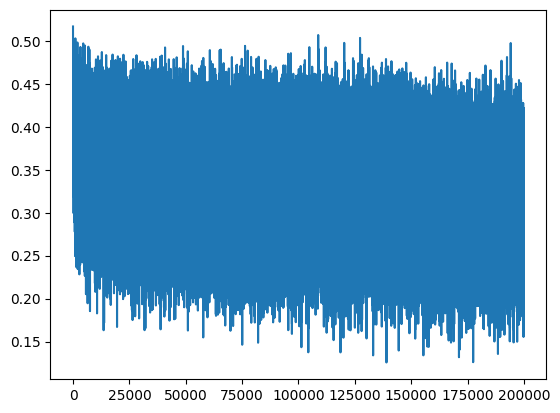

In [9]:
plt.plot(lossi);

In [10]:
#Let's also determine the training and validation losses at this point:

# Put layers into eval mode (needed for batchnorm ESPECIALLY)
for layer in layers:
    layer.training = False

# See Makemore #2.
# We did this before but it's refactored here for convenience:
@torch.no_grad() # Decorator, disables gradient tracking (no "book-keeping" on torch's side for this function)
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]   # That's a switch!
    
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # Concatenate into (N, block_size * n_embd)
    
    for layer in layers:
        x = layer(x)
    
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0592360496520996
val 2.1084988117218018


In [11]:
# Sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # Forward pass though the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1)   # Concatenate the vectors, "streching them out"
      for layer in layers:
            x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # Sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # Shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # As soon as we sample the special '.' token, break
      if ix == 0:
        break
    
    # Decode and print the generated words (Inferences)
    print(''.join(itos[i] for i in out))

karley.
jerlyn.
zharley.
brie.
lavion.
kenlie.
dilynn.
iziel.
ree.
suranko.
jakotalias.
lor.
saya.
haryo.
tyra.
daizaisias.
mahaddariti.
zyra.
ula.
karius.
